<a href="https://colab.research.google.com/github/bukharilab/BurnoutSurveillanceAI/blob/main/Final_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
from datetime import datetime

import matplotlib.pyplot as plt

ROOT = "/content/drive/MyDrive/Colab Notebooks/Burnout/Data"
paths = {
    'discharge': f'{ROOT}/discharge.csv',
    'admissions': f'{ROOT}/admissions.csv',
    '10k_sentiment': f'{ROOT}/discharge_10k_with_biobert_finetuned_sentiment.csv',
    'temporal_feat': f'{ROOT}/temporal_clinician_features_full.csv',
    'procedures': f'{ROOT}/procedureevents.csv'
}

In [ ]:
temp = pd.read_csv(paths["temp_features_full"], low_memory=False)
print(temp.shape)
print(temp.columns.tolist())
temp.head()

(1660, 28)
['CLINICIAN_ID', 'months_observed', 'mean_note_count', 'total_notes', 'mean_word_count', 'mean_hour_std', 'mean_after_hours', 'mean_days_active', 'load_mean', 'load_std', 'load_last', 'load_last3', 'load_slope3', 'frag_mean', 'frag_std', 'frag_last', 'frag_last3', 'frag_slope3', 'flex_mean', 'flex_std', 'flex_last', 'flex_last3', 'flex_slope3', 'TII_mean', 'TII_std', 'TII_last', 'TII_last3', 'TII_slope3']


,CLINICIAN_ID,months_observed,mean_note_count,total_notes,mean_word_count,mean_hour_std,mean_after_hours,mean_days_active,load_mean,load_std,...,flex_mean,flex_std,flex_last,flex_last3,flex_slope3,TII_mean,TII_std,TII_last,TII_last3,TII_slope3
0,P00230,1,1.000000,1,2411.000000,NaN,1.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000
1,P004G6,12,1.000000,12,1608.583333,NaN,0.416667,1.000000,-5.551115e-17,0.995094,...,1.295260e-16,0.999998,0.809172,1.618344e-01,0.000000,-6.245005e-17,0.533577,0.247780,-6.982202e-02,0.373392
2,P00628,183,1.103825,202,1581.893443,3.940943,0.359745,1.103825,2.273910e-16,0.997141,...,-2.615356e-17,0.999999,-0.004145,-2.215983e-01,0.326180,8.425258e-17,0.443925,-0.084111,-1.787498e-01,0.048123
3,P0090O,3,1.000000,3,1104.000000,NaN,0.333333,1.000000,-3.608225e-16,0.994914,...,-7.401487e-17,0.999998,0.577349,-7.401487e-17,0.000000,-7.401487e-17,0.646164,-0.210368,-7.401487e-17,0.152199
4,P00DF0,18,1.000000,18,863.444444,NaN,0.444444,1.000000,4.564250e-16,0.997758,...,-9.868649e-17,0.999998,0.869225,2.173063e-01,0.977878,1.850372e-16,0.528546,-0.544096,-1.156686e-01,-0.248724


In [ ]:
weekly = pd.read_csv(paths['weekly_features'])
weekly.columns

Index(['CLINICIAN_ID', 'WEEK', 'note_count', 'avg_tokens', 'mean_gap_mins',
       'after_hours_ratio', 'hour_std', 'linearity_raw', 'flex_raw',
       'pace_raw', 'scarcity_raw', 'flex_n', 'pace_n', 'lin_n', 'scar_n',
       'TII'],
      dtype='object')

# Weakly Supervised Ordinal Risk Labeling
1. Align everything by provider
2. Build a table of signals (note count, high notes, cause mentions, max shift hours)
3. Normalize emotional distress (high ratio = high notes/ total notes)
4. Decide what high means (in this case we used 80th percentile)
5. Use these thresholds to then flag the respective signal
6. Aggregate evidence by voting
7. Assign risk labels from the voting (0-1 = low risk, >2 = medium risk, etc.)
8. Collapse into binary label (logistic regression friendly)
9. Return labeled provider table


In [ ]:
def build_risk_labels(
    prov_metrics: pd.DataFrame,
    prov_summary: pd.DataFrame,
    max_shift_hours: pd.Series,
    *,
    q_hi: float = 0.80,
    use_high_ratio: bool = True,
    temporal_trends: pd.DataFrame | None = None,
    trend_col: str = "delta_sent_per_day",
    q_lo: float = 0.20,
    include_trend_flag: bool = False,
    keep_flags: bool = True,
    binary_from: str = "high_only",  # "high_only" or "med_or_high"
) -> pd.DataFrame:
    """
    Build ordinal (Low/Medium/High) provider risk labels from weak signals.

    Inputs (index-aligned by PROVIDER_ID):
      - prov_metrics: provider-level metrics, must contain NOTE_COUNT
      - prov_summary: provider-level counts, must contain HIGH_NOTES and CAUSE_MENTIONS
      - max_shift_hours: Series indexed by PROVIDER_ID (max shift duration per provider)
      - temporal_trends: optional provider-level table with trend_col

    Returns:
      DataFrame indexed by PROVIDER_ID with:
        HIGH_NOTES, CAUSE_MENTIONS, NOTE_COUNT, HIGH_RATIO, MAX_SHIFT_HOURS,
        flags (optional), EVIDENCE_COUNT, RISK_LEVEL (0/1/2), RISK_LABEL, BURNOUT_LABEL
    """

    # --- Normalize indices ---
    def _as_str_index(df_or_s):
        if isinstance(df_or_s, pd.Series):
            s = df_or_s.copy()
            s.index = s.index.map(str)
            return s
        df = df_or_s.copy()
        df.index = df.index.map(str)
        return df

    prov_metrics = _as_str_index(prov_metrics)
    prov_summary = _as_str_index(prov_summary)
    max_shift_hours = _as_str_index(max_shift_hours)

    # --- Base label frame ---
    needed_pm = ["NOTE_COUNT"]
    for c in needed_pm:
        if c not in prov_metrics.columns:
            raise KeyError(f"prov_metrics must contain '{c}'")

    needed_ps = ["HIGH_NOTES", "CAUSE_MENTIONS"]
    for c in needed_ps:
        if c not in prov_summary.columns:
            raise KeyError(f"prov_summary must contain '{c}'")

    label_df = prov_metrics[["NOTE_COUNT"]].join(
        prov_summary[["HIGH_NOTES", "CAUSE_MENTIONS"]],
        how="left"
    ).fillna(0)

    # High ratio (more stable than raw high notes count)
    if use_high_ratio:
        label_df["HIGH_RATIO"] = (
            label_df["HIGH_NOTES"] / label_df["NOTE_COUNT"].replace({0: np.nan})
        ).fillna(0)
        neg_signal = "HIGH_RATIO"
    else:
        neg_signal = "HIGH_NOTES"

    # Add MAX_SHIFT_HOURS
    label_df = label_df.join(
        max_shift_hours.rename("MAX_SHIFT_HOURS"),
        how="left"
    ).fillna({"MAX_SHIFT_HOURS": 0})

    # Optional: add trend column
    if include_trend_flag:
        if temporal_trends is None:
            raise ValueError("include_trend_flag=True requires temporal_trends.")
        temporal_trends = _as_str_index(temporal_trends)
        if trend_col not in temporal_trends.columns:
            raise KeyError(f"temporal_trends must contain '{trend_col}'")
        label_df = label_df.join(temporal_trends[[trend_col]], how="left").fillna({trend_col: 0})

    # --- Robust quantile helper (handles constant columns) ---
    def _q(series: pd.Series, q: float) -> float:
        s = pd.to_numeric(series, errors="coerce").dropna()
        if s.empty:
            return 0.0
        return float(s.quantile(q))

    # --- Flags (top-quintile style) ---
    neg_thr   = _q(label_df[neg_signal], q_hi)
    cause_thr = _q(label_df["CAUSE_MENTIONS"], q_hi)
    shift_thr = _q(label_df["MAX_SHIFT_HOURS"], q_hi)

    label_df["neg_flag"]   = (label_df[neg_signal] >= neg_thr).astype(int)
    label_df["cause_flag"] = (label_df["CAUSE_MENTIONS"] >= cause_thr).astype(int)
    label_df["shift_flag"] = (label_df["MAX_SHIFT_HOURS"] >= shift_thr).astype(int)

    flag_cols = ["neg_flag", "cause_flag", "shift_flag"]

    if include_trend_flag:
        # Worsening sentiment trend = bottom quantile (more negative)
        trend_thr = _q(label_df[trend_col], q_lo)
        label_df["trend_flag"] = (label_df[trend_col] <= trend_thr).astype(int)
        flag_cols.append("trend_flag")

    # --- Vote count ---
    label_df["EVIDENCE_COUNT"] = label_df[flag_cols].sum(axis=1)

    # --- 3-level risk (0/1/2) ---
    # 0: evidence 0–1, 1: evidence 2, 2: evidence 3+
    label_df["RISK_LEVEL"] = pd.cut(
        label_df["EVIDENCE_COUNT"],
        bins=[-1, 1, 2, 99],
        labels=[0, 1, 2]
    ).astype(int)

    label_df["RISK_LABEL"] = label_df["RISK_LEVEL"].map({0: "Low", 1: "Medium", 2: "High"})

    # --- Optional binary label ---
    if binary_from == "high_only":
        label_df["BURNOUT_LABEL"] = (label_df["RISK_LEVEL"] == 2).astype(int)
    elif binary_from == "med_or_high":
        label_df["BURNOUT_LABEL"] = (label_df["RISK_LEVEL"] >= 1).astype(int)
    else:
        raise ValueError("binary_from must be 'high_only' or 'med_or_high'")

    # --- Optionally drop flags for cleaner downstream ---
    if not keep_flags:
        label_df = label_df.drop(columns=flag_cols, errors="ignore")

    return label_df

# Get the Sentiment Analysis File

In [ ]:
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -------------------------------
# CONFIG
# -------------------------------
RAW_NOTES_CSV = paths['discharge']  # whatever your raw export is called
OUTPUT_CSV    = "discharge_10k_with_biobert_finetuned_sentiment.csv"
MODEL_NAME    = "emilyalsentzer/Bio_ClinicalBERT"  # or your fine-tuned checkpoint
BATCH_SIZE    = 16
MAX_LEN       = 256  # or 512 depending on GPU/CPU

# -------------------------------
# LOAD RAW NOTES
# Expect at least: subject_id, hadm_id, text
# -------------------------------
notes = pd.read_csv(RAW_NOTES_CSV, low_memory=False)
notes = notes.rename(columns={
    "subject_id": "subject_id",
    "hadm_id":    "hadm_id",
    "text":       "text"
})
notes = notes.dropna(subset=["text"]).reset_index(drop=True)

# -------------------------------
# LOAD BIOBERT MODEL
# (Assumes it is fine-tuned on your sentiment task)
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.to(device)
model.eval()

label_map = {0: "negative", 1: "neutral", 2: "positive"}  # adjust to your fine-tuning

# -------------------------------
# RUN SENTIMENT INFERENCE
# -------------------------------
all_scores = []
all_labels = []

texts = notes["text"].tolist()

for i in tqdm(range(0, len(texts), BATCH_SIZE)):
    batch_texts = texts[i:i + BATCH_SIZE]

    enc = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**enc).logits
        probs  = torch.softmax(logits, dim=-1)

    # sentiment_score = max probability
    max_probs, preds = probs.max(dim=-1)

    all_scores.extend(max_probs.cpu().tolist())
    all_labels.extend([label_map[int(p)] for p in preds.cpu().tolist()])

notes["sentiment_score"] = all_scores
notes["sentiment_label"] = all_labels

# -------------------------------
# SAVE MUTATED NOTES FILE
# -------------------------------
notes.to_csv(OUTPUT_CSV, index=False)
print(f"Saved BioBERT sentiment notes to {OUTPUT_CSV}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 20738/20738 [27:43<00:00, 12.46it/s]


Saved BioBERT sentiment notes to discharge_10k_with_biobert_finetuned_sentiment.csv


# Final Pipeline

In [ ]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.5 MB/s eta 0:00:00


In [ ]:
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import os, time, re
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import pyLDAvis
from IPython.display import display, HTML
pyLDAvis.enable_notebook()

import spacy
nlp = spacy.load(
    "en_core_web_sm",
    disable=["tagger", "parser", "attribute_ruler", "lemmatizer"]
)
from tqdm import tqdm

# -------------------------------
# STEP 0: VERIFY REQUIRED FILES
# -------------------------------
required_files = [
    paths['10k_sentiment'],
    paths['admissions'],
    paths['procedures'],
    paths['temporal_feat']
]
missing = [f for f in required_files if not os.path.isfile(f)]
if missing:
    raise FileNotFoundError(f"Missing required files: {missing}")
print("All required CSVs found.\n")

# -------------------------------
# STEP 1: LOAD NOTES + SENTIMENT
# -------------------------------
print("1) Loading notes + BioBERT sentiment…")
t0 = time.time()
notes = pd.read_csv(
    paths['10k_sentiment'],
    low_memory=False
)
print(f"   → Loaded in {round(time.time() - t0,1)} s; rows = {len(notes)}\n")

notes = notes.rename(columns={
    'subject_id': 'SUBJECT_ID',
    'hadm_id':    'HADM_ID',
    'text':       'TEXT'
})

if 'sentiment_score' not in notes.columns:
    raise KeyError("Expected 'sentiment_score' in notes CSV.")

# -------------------------------
# STEP 2: MERGE PROVIDER_ID (admissions)
# -------------------------------
print("2) Merging PROVIDER_ID via admissions.csv…")
t0 = time.time()
admissions_inf = (
    pd.read_csv(paths['admissions'], usecols=['hadm_id','admit_provider_id'], low_memory=False)
      .rename(columns={'admit_provider_id':'PROVIDER_ID'})
      .dropna(subset=['PROVIDER_ID'])
)

adm_inf_sample = admissions_inf[admissions_inf['hadm_id'].isin(notes['HADM_ID'])]
primary_providers = adm_inf_sample[['hadm_id','PROVIDER_ID']].drop_duplicates()
primary_providers = primary_providers.rename(columns={'PROVIDER_ID':'PRIMARY_PROVIDER_ID'})

notes = notes.merge(primary_providers, how='inner', left_on='HADM_ID', right_on='hadm_id')
notes = notes.drop(columns=['hadm_id']).rename(columns={'PRIMARY_PROVIDER_ID':'PROVIDER_ID'})
notes['PROVIDER_ID'] = notes['PROVIDER_ID'].astype(str)
print(f"   → After merging providers, notes shape: {notes.shape}\n")

# -------------------------------
# STEP 3: BUILD DATETIME
# -------------------------------
print("3) Constructing DATETIME…")
if {'CHARTDATE','CHARTTIME'}.issubset(notes.columns):
    notes['DATETIME'] = pd.to_datetime(
        notes['CHARTDATE'].astype(str) + ' ' + notes['CHARTTIME'].astype(str),
        errors='coerce'
    )
elif 'CHARTDATE' in notes.columns:
    notes['DATETIME'] = pd.to_datetime(notes['CHARTDATE'], errors='coerce')
elif 'storetime' in notes.columns:
    notes['DATETIME'] = pd.to_datetime(notes['storetime'], errors='coerce')
else:
    raise KeyError("No CHARTDATE+CHARTTIME or storetime found.")

before_drop = len(notes)
notes = notes.dropna(subset=['DATETIME']).copy()
after_drop  = len(notes)
print(f"   → Dropped {before_drop - after_drop} rows with NaT DATETIME. Remaining: {after_drop}\n")

# -------------------------------
# STEP 4: PER-NOTE FEATURES
# -------------------------------
print("4) Computing per-note features…")

# basic counts
notes['WORD_COUNT'] = notes['TEXT'].str.split().str.len()
notes['SENT_COUNT'] = notes['TEXT'].str.count(r'[\.!?]') + 1
notes['WPS']        = notes['WORD_COUNT'] / notes['SENT_COUNT']

# pronouns
pron_pat = re.compile(r'\b(I|we|me|us|my|our|mine|ours)\b', re.IGNORECASE)
notes['PRONOUN_COUNT'] = notes['TEXT'].str.count(pron_pat)

# cleaned text (remove some outcome/clinical terms)
clin_terms = [
    r'\bdeath(ed|s)?\b', r'\bexpired\b',   r'\bdeceased\b',
    r'\bdie(ing|d)?\b',  r'\bworse(d)?\b', r'\bimprov(ed|ing)?\b',
    r'\balive\b',        r'\bstable\b',    r'\bsepsis\b'
]
clin_pattern = '|'.join(clin_terms)
notes['TEXT_CLEAN'] = notes['TEXT'].str.replace(clin_pattern, '', regex=True)
notes['TEXT_CLEAN'] = notes['TEXT_CLEAN'].str.replace(r'\b_+\b', ' ', regex=True)
notes['TEXT_CLEAN'] = notes['TEXT_CLEAN'].str.replace(r'\s+', ' ', regex=True).str.strip()

# sentiment label → bin
notes['SENTIMENT_BIN'] = notes['sentiment_label']
print("   → Per-note features done.\n")

# -------------------------------
# STEP 5: SPECIALTY ASSIGNMENT
# -------------------------------
print("5) Extracting specialties…")
service_pat = re.compile(r"Service:\s*([A-Z][A-Z ]+)\b")
notes["RAW_SERVICE"] = (
    notes["TEXT"]
         .str.extract(service_pat, expand=False)
         .str.title()
         .fillna("Unknown")
)

base_specialties = {
    "Internal Medicine", "Neurology", "Psychiatry", "Surgery",
    "Emergency", "Orthopedics", "Cardiology", "Radiology",
    "Urology", "Obstetrics", "Ophthalmology"
}
variant_map = {
    "Med":        "Internal Medicine",
    "Medicine":   "Internal Medicine",
    "Med-Surg":   "Internal Medicine",
    "Med Surg":   "Internal Medicine",
    "Med/Onc":    "Internal Medicine",
    "Internal Med": "Internal Medicine",
    "Intern Med": "Internal Medicine",
    "Neuro":      "Neurology",
    "Psych":      "Psychiatry",
    "Surg":       "Surgery",
    "Emerg":      "Emergency",
    "Ortho":      "Orthopedics",
    "Cardio":     "Cardiology",
    "Rad":        "Radiology",
    "Ob/Gyn":     "Obstetrics",
}
specialty_keywords = {
    "Internal Medicine": [
        r"\bhypertension\b", r"\bdiabet(es|ic)\b",
        r"\bheart failure\b", r"\bsepsis\b", r"\bmetformin\b",
        r"\bhba1c\b",         r"\batherosclerosis\b"
    ],
    "Neurology":   [r"\bstroke\b", r"\bseizure\b", r"\bneuropath(y|ic)\b", r"\bEEG\b", r"\bMS\b"],
    "Psychiatry":  [r"\bdepress(ion|ive)\b", r"\banxi(et(y|ies))\b", r"\bpsychotic\b", r"\bbipolar\b", r"\bschizophrenic\b"],
    "Surgery":     [r"\boperat(e|ion)\b", r"\bpost[- ]op\b", r"\blaparoscop(y|ical)\b", r"\bincision\b", r"\bsuture\b"],
    "Emergency":   [r"\bcode blue\b", r"\btrauma\b", r"\bCPR\b", r"\bart(ery|rial) line\b"],
    "Orthopedics": [r"\bfracture\b", r"\bsplint\b", r"\bart(hro|hi)scop(y|ic)\b", r"\bjoint replacement\b"],
    "Cardiology":  [r"\bcardiomyopathy\b", r"\bMI\b", r"\bECG\b", r"\bangina\b", r"\barrhythmia\b"],
    "Radiology":   [r"\bCT scan\b", r"\bMRI\b", r"\bradiograph(y|ic)\b", r"\bultrasound\b", r"\bPET scan\b"],
    "Urology":     [r"\bkidney stone\b", r"\bhematuria\b", r"\bprostat(e|ic)\b", r"\bnephrolithiasis\b"],
    "Obstetrics":  [r"\bprenatal\b", r"\blabor\b", r"\bC[- ]section\b", r"\bgestation\b", r"\bpostpartum\b"],
    "Ophthalmology":[r"\bvision\b", r"\bretina\b", r"\bglaucoma\b", r"\bocular\b", r"\bmaculopathy\b"]
}
for cat, pats in specialty_keywords.items():
    specialty_keywords[cat] = [re.compile(p, re.IGNORECASE) for p in pats]

def assign_specialty(row):
    raw = row["RAW_SERVICE"]
    if raw in variant_map:
        return variant_map[raw]
    text = row["TEXT_CLEAN"]
    for cat, patterns in specialty_keywords.items():
        for pat in patterns:
            if pat.search(text):
                return cat
    return "Other"

notes["SPECIALTY"] = notes.apply(assign_specialty, axis=1)
all_categories = list(base_specialties) + ["Other"]
notes["SPECIALTY"] = pd.Categorical(notes["SPECIALTY"], categories=all_categories, ordered=True)
print(notes["SPECIALTY"].value_counts(dropna=False), "\n")

# -------------------------------
# STEP 6: spaCy ENTITIES (snippet)
# -------------------------------
print("6) Extracting spaCy entities…")
ents_list = []
for doc in tqdm(nlp.pipe(notes["TEXT_CLEAN"].str[:1000], batch_size=100), total=len(notes)):
    ents_list.append([ent.text for ent in doc.ents])
notes["SPACY_ENTS"] = ents_list
print("   → spaCy entities extracted.\n")

# -------------------------------
# STEP 7: SEVERITY FROM SENTIMENT
# -------------------------------
notes["SEVERITY"] = notes["sentiment_label"].map({
    "negative": "High",
    "neutral":  "Medium",
    "positive": "Low"
})
print("7) Created SEVERITY column.\n")

# -------------------------------
# STEP 8: PER-PROVIDER METRICS
# -------------------------------
print("8) Computing per-provider metrics…")
grp = notes.groupby('PROVIDER_ID')
prov_metrics = pd.DataFrame({
    'NOTE_COUNT':   grp.size(),
    'AVG_WORDS':    grp['WORD_COUNT'].mean(),
    'AVG_SENTS':    grp['SENT_COUNT'].mean(),
    'AVG_WPS':      grp['WPS'].mean(),
    'AVG_PRONOUNS': grp['PRONOUN_COUNT'].mean()
})

# placeholder (no actual proc counts here)
prov_metrics['AVG_PROCS_PER_NOTE'] = 0

# unique admissions per provider
patient_load = (
    notes[['PROVIDER_ID','HADM_ID']]
      .drop_duplicates()
      .groupby('PROVIDER_ID')['HADM_ID']
      .nunique()
      .rename('PATIENT_LOAD')
)
prov_metrics = prov_metrics.join(patient_load, how='left')

# mortality rate
admissions_mort = pd.read_csv(paths['admissions'], usecols=['hadm_id','hospital_expire_flag'], low_memory=False)
mort_data = (
    notes[['PROVIDER_ID','HADM_ID']]
        .drop_duplicates()
        .merge(admissions_mort, left_on='HADM_ID', right_on='hadm_id', how='left')
        .drop(columns=['hadm_id'])
)
mortality_rate = (
    mort_data.groupby('PROVIDER_ID')['hospital_expire_flag']
             .mean()
             .rename('MORTALITY_RATE')
)
prov_metrics = prov_metrics.join(mortality_rate, how='left').fillna({'MORTALITY_RATE': 0})
prov_metrics.index = prov_metrics.index.map(str)
print(prov_metrics.head(), "\n")

# -------------------------------
# 8.5 LOAD TEMPORAL DYNAMICS FEATURES (provider-level)
# -------------------------------
print("8.5) Loading temporal dynamics features…")
temp_full = pd.read_csv(paths["temporal_feat"], low_memory=False)

# Standardize ID column name -> PROVIDER_ID
if "PROVIDER_ID" in temp_full.columns:
    temp_full["PROVIDER_ID"] = temp_full["PROVIDER_ID"].astype(str)
    temp_full = temp_full.set_index("PROVIDER_ID")
elif "CLINICIAN_ID" in temp_full.columns:
    temp_full["CLINICIAN_ID"] = temp_full["CLINICIAN_ID"].astype(str)
    temp_full = temp_full.rename(columns={"CLINICIAN_ID": "PROVIDER_ID"}).set_index("PROVIDER_ID")
else:
    raise KeyError("temporal_feat must contain PROVIDER_ID or CLINICIAN_ID")

temporal_cols = ["load_last3", "frag_last3", "flex_last3"]
temp_use = temp_full[temporal_cols].copy()

print("   → Temporal features loaded:", temp_use.shape)

# -------------------------------
# STEP 9: TOP-20 UNIGRAMS & BIGRAMS (EDA)
# -------------------------------
def show_ngrams(ngram_range, title):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=20)
    tf = vec.fit(notes['TEXT_CLEAN'])
    mat = tf.transform(notes['TEXT_CLEAN'])
    freqs = np.asarray(mat.sum(axis=0)).ravel()
    df = pd.DataFrame({'Term': vec.get_feature_names_out(), 'Freq': freqs})
    df = df.sort_values('Freq', ascending=False).reset_index(drop=True)
    df.index += 1
    df.index.name = 'Rank'
    print(f"\n=== {title} ===")
    display(df)
    return df

uni_df_top20 = show_ngrams((1,1), "Unigram Frequencies (Top 20)")
bi_df_top20  = show_ngrams((2,2), "Bigram Frequencies (Top 20)")

# -------------------------------
# STEP 10: LDA TOPICS (5)
# -------------------------------
print("10) Running LDA (5 topics)…")
v_lda = CountVectorizer(stop_words='english', max_features=1000)
dtm   = v_lda.fit_transform(notes['TEXT_CLEAN'])

lda = LatentDirichletAllocation(n_components=5, random_state=0)
doc_topic = lda.fit_transform(dtm)

doc_lengths = np.asarray(dtm.sum(axis=1)).ravel().tolist()
term_freqs  = np.asarray(dtm.sum(axis=0)).ravel().tolist()
panel = pyLDAvis.prepare(
    topic_term_dists=lda.components_,
    doc_topic_dists=doc_topic,
    doc_lengths=doc_lengths,
    vocab=v_lda.get_feature_names_out(),
    term_frequency=term_freqs,
    mds='pcoa',
    sort_topics=False
)
pyLDAvis.save_html(panel, "lda_mimiciv_sample_pcoa_visualization.html")

# -------------------------------
# STEP 11: SHIFTS (WORK HOURS) & PLOTS
# -------------------------------
print("11) Computing shifts (for long-hour proxy)…")
shifts = (
    notes
    .groupby(['PROVIDER_ID', notes['DATETIME'].dt.date])['DATETIME']
    .agg(min_dt='min', max_dt='max')
)
shifts['HOURS'] = (shifts['max_dt'] - shifts['min_dt']).dt.total_seconds() / 3600

# -------------------------------
# STEP 12: BURNOUT CAUSES & SUMMARY
# -------------------------------
print("12) Computing burnout causes summary…")
cause_lex = [
    ('Long Hours',        [r'\b(hours?|overtime|extended shift|overnight|on[- ]call)\b']),
    ('Resource Issues',   ['shortage','no bed','staffing','understaffed','ppe','supplies']),
    ('Comm Breakdown',    ['handoff','miscommunication','consult','phone tag']),
    ('Patient Complexity',['comorbid','polytrauma','multisystem','complicated','polypharmacy']),
    ('Moral Distress',    ['guilt','ethical dilemma','burnout','overwhelmed','frustrated']),
    ('High Acuity',       ['code blue','arrest','resuscitation','trauma','ICU']),
    ('Admin Load',        ['paperwork','documentation','charting','billing','EHR'])
]
cause_patterns = [(lbl, re.compile('|'.join(pats), re.IGNORECASE)) for lbl,pats in cause_lex]
cause_entities = {
    'Long Hours':        {'overtime', 'extended shift', 'on call'},
    'Resource Issues':   {'ppe', 'staffing shortage', 'no bed'},
    'Comm Breakdown':    {'handoff', 'miscommunication', 'phone tag'},
    'Patient Complexity':{'polytrauma', 'multisystem', 'polypharmacy'},
    'Moral Distress':    {'guilt', 'ethical dilemma', 'overwhelmed', 'frustrated'},
    'High Acuity':       {'code blue', 'arrest', 'resuscitation', 'trauma'},
    'Admin Load':        {'paperwork', 'documentation', 'charting', 'billing', 'ehr'}
}

def assign_causes(row):
    text = row["TEXT_CLEAN"]
    ents = {e.lower() for e in row["SPACY_ENTS"]}
    causes_found = []
    for label, pat in cause_patterns:
        if pat.search(text):
            causes_found.append(label)
    for label, ent_set in cause_entities.items():
        if ents & ent_set:
            causes_found.append(label)
    return list(set(causes_found))

df_text = (
    notes[['PROVIDER_ID','TEXT_CLEAN','SPACY_ENTS']]
         .assign(CAUSES=lambda dfd: dfd.apply(assign_causes, axis=1))
         .explode('CAUSES')
         .dropna(subset=['CAUSES'])
         [['PROVIDER_ID','CAUSES']]
         .rename(columns={'CAUSES':'CAUSE'})
)

text_counts = df_text.groupby(['PROVIDER_ID','CAUSE']).size().rename('count').reset_index()

# add long-hours flag from shifts (> 8 hours)
max_shift = shifts.groupby('PROVIDER_ID')['HOURS'].max()
shift_flag = (
    max_shift[max_shift > 8]
         .reset_index()
         .assign(CAUSE='Long Hours', count=1)
         [['PROVIDER_ID','CAUSE','count']]
)

all_counts = pd.concat([text_counts, shift_flag], ignore_index=True)
combined   = (
    all_counts.groupby(['PROVIDER_ID','CAUSE'])['count']
             .sum()
             .reset_index()
)

top_causes = (
    combined.sort_values(['PROVIDER_ID','count'], ascending=[True,False])
            .groupby('PROVIDER_ID')
            .head(2)
)
severity_mode = (
    notes.groupby('PROVIDER_ID')['SEVERITY']
         .agg(lambda s: s.mode()[0] if not s.mode().empty else pd.NA)
         .rename('Modal_Severity_of_Notes')
)
burnout_phys_summary = (
    top_causes.groupby('PROVIDER_ID')['CAUSE']
              .agg(', '.join)
              .reset_index()
              .rename(columns={'CAUSE':'Top_Causes'})
)
burnout_phys_summary = burnout_phys_summary.merge(severity_mode, on='PROVIDER_ID', how='left')
burnout_phys_summary.to_csv('sample_provider_top2_burnout_causes_with_severity.csv', index=False)

# -------------------------------
# STEP 13: TEMPORAL TRENDS
# -------------------------------
# We made a more robust temporal pipeline
print("13) Computing temporal trends…")
first_ts    = notes.groupby('PROVIDER_ID')['DATETIME'].min().rename('first_ts')
last_ts     = notes.groupby('PROVIDER_ID')['DATETIME'].max().rename('last_ts')
span_days   = ((last_ts - first_ts).dt.days).rename('span_days')

sent_first  = notes.sort_values('DATETIME').groupby('PROVIDER_ID')['sentiment_score'].first().rename('sent_first')
sent_last   = notes.sort_values('DATETIME').groupby('PROVIDER_ID')['sentiment_score'].last().rename('sent_last')
delta_sent  = (sent_last - sent_first).rename('delta_sent')
delta_per_day = ((delta_sent / span_days.replace({0: np.nan})).fillna(0)).rename('delta_sent_per_day')

months_active = ((span_days / 30).clip(lower=1)).rename('months_active')

cause_counts    = df_text.groupby('PROVIDER_ID').size().rename('total_cause_mentions')
cause_per_month = ((cause_counts / months_active).fillna(0)).rename('cause_per_month')

temporal_trends = pd.concat(
    [span_days, delta_per_day, months_active, cause_per_month],
    axis=1
).fillna(0)
print(temporal_trends.head(), "\n")

# -------------------------------
# STEP 14: LOGISTIC REGRESSION MODEL
# -------------------------------
print("14) Building logistic regression model…")

#----------------------------------------------------------------------------

# silver label: HIGH notes + cause mentions

# We can make a much stronger labelling module
# Why specifically 12 negative notes & 7 cause mentions? Doesnt have enough basis to be put on the paper
# Burnout is multidimensional but this labelling method collapses burnout to sentiment and count based. Burnout is expressed differently accross people
# Solution: find a way to make this less strict but still providing a label through binary means in the end, maybe a voting method
# Previous method:
# high_counts   = notes[notes["SEVERITY"] == "High"].groupby("PROVIDER_ID").size().rename("HIGH_NOTES")
# cause_counts2 = df_text.groupby("PROVIDER_ID").size().rename("CAUSE_MENTIONS")

# prov_summary = pd.DataFrame({
#     "HIGH_NOTES":     high_counts,
#     "CAUSE_MENTIONS": cause_counts2
# }).fillna(0)

# prov_summary["BURNOUT_LABEL"] = (
#     (prov_summary["HIGH_NOTES"]     >= 12) &
#     (prov_summary["CAUSE_MENTIONS"] >= 7)
# ).astype(int)

# print("Silver‐standard label distribution:")
# print(prov_summary["BURNOUT_LABEL"].value_counts(), "\n")



high_counts   = notes[notes["SEVERITY"] == "High"].groupby("PROVIDER_ID").size().rename("HIGH_NOTES")
cause_counts2 = df_text.groupby("PROVIDER_ID").size().rename("CAUSE_MENTIONS")

prov_summary = pd.DataFrame({
    "HIGH_NOTES":     high_counts,
    "CAUSE_MENTIONS": cause_counts2
}).fillna(0)
prov_summary.index = prov_summary.index.map(str)

# max_shift_hours is a Series indexed by PROVIDER_ID
max_shift_hours = shifts.groupby("PROVIDER_ID")["HOURS"].max()

# prov_summary is what you already build: HIGH_NOTES and CAUSE_MENTIONS
# prov_metrics is your provider metrics table with NOTE_COUNT

labels = build_risk_labels(
    prov_metrics=prov_metrics,
    prov_summary=prov_summary,
    max_shift_hours=max_shift_hours,
    q_hi=0.80,
    use_high_ratio=True,
    include_trend_flag=False,  # set True if you join temporal trends
    keep_flags=True,
    binary_from="med_or_high",
)

print(labels["RISK_LABEL"].value_counts())
print(labels["BURNOUT_LABEL"].value_counts())


# ---------------------------------------------------------------------------


# feature matrix: prov_metrics + cause counts
cause_counts_per_provider = (
    df_text.groupby(["PROVIDER_ID","CAUSE"])
           .size()
           .unstack(fill_value=0)
)

# Join labels into your feature table
features = (
    prov_metrics
    .join(cause_counts_per_provider, how="left")
    .join(temp_use, how="left")     # <-- temporal dynamics added
    .fillna(0)
)
data = features.join(labels[["RISK_LEVEL", "BURNOUT_LABEL"]], how="inner")

X = data.drop(columns=["RISK_LEVEL", "BURNOUT_LABEL"])
y = data["BURNOUT_LABEL"]  # or y = data["RISK_LEVEL"] for 3-level

print("Feature matrix shape:", X.shape)
print("Burnout label distribution:\n", y.value_counts(), "\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm, "\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["Not Burned-Out","Burned-Out"]))
f1 = f1_score(y_test, y_pred)
print(f"Overall F1 (Burned-Out class): {f1:.2f}\n")

# OPTIONAL: export full provider-level feature + label table
data.reset_index().rename(columns={'index': 'PROVIDER_ID'}).to_csv(
    "provider_burnout_features_and_labels.csv", index=False
)

print("Pipeline completed successfully.")

All required CSVs found.

1) Loading notes + BioBERT sentiment…
   → Loaded in 1.3 s; rows = 10000

2) Merging PROVIDER_ID via admissions.csv…
   → After merging providers, notes shape: (10000, 13)

3) Constructing DATETIME…
   → Dropped 1 rows with NaT DATETIME. Remaining: 9999

4) Computing per-note features…
   → Per-note features done.

5) Extracting specialties…
SPECIALTY
Internal Medicine    7877
Neurology             975
Surgery               587
Psychiatry            362
Emergency              45
Other                  43
Orthopedics            39
Radiology              36
Urology                16
Cardiology             13
Obstetrics              4
Ophthalmology           2
Name: count, dtype: int64 

6) Extracting spaCy entities…


100%|██████████| 9999/9999 [02:15<00:00, 73.60it/s]


   → spaCy entities extracted.

7) Created SEVERITY column.

8) Computing per-provider metrics…
             NOTE_COUNT    AVG_WORDS   AVG_SENTS    AVG_WPS  AVG_PRONOUNS  \
PROVIDER_ID                                                                 
P00628                8  2019.125000  191.375000  11.380523      5.125000   
P00H9O                2  1831.000000  126.000000  14.491288      4.500000   
P00HGT              170  1471.611765  151.152941   9.863843      2.241176   
P0124R                2  2154.500000  198.500000  10.861196      8.500000   
P014BG                1  1525.000000  164.000000   9.298780      0.000000   

             AVG_PROCS_PER_NOTE  PATIENT_LOAD  MORTALITY_RATE  
PROVIDER_ID                                                    
P00628                        0             8        0.000000  
P00H9O                        0             2        0.000000  
P00HGT                        0           170        0.011765  
P0124R                        0             

,Term,Freq
Rank,,
1,mg,172755
2,po,144625
3,blood,101694
4,daily,99683
5,discharge,92016
6,patient,81636
7,pain,79366
8,tablet,78325
9,history,64624



=== Bigram Frequencies (Top 20) ===


,Term,Freq
Rank,,
1,mg po,88512
2,po daily,56494
3,mg tablet,33548
4,po bid,22270
5,sig tablet,21919
6,tablet sig,20395
7,tablet po,18495
8,physical exam,15245
9,tablet refills,14400


10) Running LDA (5 topics)…
11) Computing shifts (for long-hour proxy)…
12) Computing burnout causes summary…
13) Computing temporal trends…
             span_days  delta_sent_per_day  months_active  cause_per_month
PROVIDER_ID                                                               
P00628           27847       -8.894164e-07     928.233333         0.024778
P00H9O            2195        1.928007e-05      73.166667         0.082005
P00HGT           31779       -1.232799e-06    1059.300000         0.479562
P0124R            6078       -2.391031e-06     202.600000         0.024679
P014BG               0        0.000000e+00       1.000000         4.000000 

14) Building logistic regression model…
RISK_LABEL
Low       604
Medium    350
High       21
Name: count, dtype: int64
BURNOUT_LABEL
0    604
1    371
Name: count, dtype: int64
Feature matrix shape: (975, 18)
Burnout label distribution:
 BURNOUT_LABEL
0    604
1    371
Name: count, dtype: int64 

Confusion matrix:
 [[97 24]
 [29 4

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Temporal Dynamics Ablation (Baseline vs +Temporal) — single Jupyter cell
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# --- REQUIRED INPUTS ---
# expects `data` already exists from your pipeline:
#   data = features.join(labels[["RISK_LEVEL", "BURNOUT_LABEL"]], how="inner")
# and temporal columns exist in data: load_last3, frag_last3, flex_last3

assert "BURNOUT_LABEL" in data.columns, "data must include BURNOUT_LABEL"
temporal_cols = ["load_last3", "frag_last3", "flex_last3"]
for c in temporal_cols:
    assert c in data.columns, f"Missing temporal column: {c}"

# --- Build X_A (no temporal) and X_B (with temporal) ---
drop_label_cols = ["RISK_LEVEL", "BURNOUT_LABEL"]
X_B = data.drop(columns=[c for c in drop_label_cols if c in data.columns])
X_A = data.drop(columns=[c for c in drop_label_cols if c in data.columns] + temporal_cols)
y = data["BURNOUT_LABEL"].astype(int)

# --- Model factory ---
def make_model(class_weight="balanced", C=1.0):
    return Pipeline([
        ("scaler", StandardScaler()),  # data is dense; StandardScaler is fine
        ("clf", LogisticRegression(
            max_iter=3000,
            class_weight=class_weight,
            C=C,
            solver="lbfgs",
        ))
    ])

def fit_eval(Xtr, Xte, ytr, yte, class_weight="balanced", C=1.0):
    model = make_model(class_weight=class_weight, C=C)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    return {
        "precision": precision_score(yte, pred, zero_division=0),
        "recall":    recall_score(yte, pred, zero_division=0),
        "f1":        f1_score(yte, pred, zero_division=0),
        "cm":        confusion_matrix(yte, pred),
    }

# --- Run multiple seeds for stability ---
seeds = [0, 1, 2, 3, 4]
rows = []

for seed in seeds:
    idx = data.index
    train_idx, test_idx = train_test_split(
        idx, test_size=0.2, random_state=seed, stratify=y
    )

    res_A = fit_eval(X_A.loc[train_idx], X_A.loc[test_idx], y.loc[train_idx], y.loc[test_idx])
    res_B = fit_eval(X_B.loc[train_idx], X_B.loc[test_idx], y.loc[train_idx], y.loc[test_idx])

    rows.append({
        "seed": seed,
        "P_no_temp": res_A["precision"],
        "R_no_temp": res_A["recall"],
        "F1_no_temp": res_A["f1"],
        "P_with_temp": res_B["precision"],
        "R_with_temp": res_B["recall"],
        "F1_with_temp": res_B["f1"],
        "ΔF1": res_B["f1"] - res_A["f1"],
    })

results = pd.DataFrame(rows)

# --- Print results table + summary ---
display(results)

def mean_std(x):
    return float(np.mean(x)), float(np.std(x, ddof=1)) if len(x) > 1 else 0.0

mA, sA = mean_std(results["F1_no_temp"])
mB, sB = mean_std(results["F1_with_temp"])
mD, sD = mean_std(results["ΔF1"])

print("\n=== Temporal Ablation Summary (High-risk / BURNOUT_LABEL=1) ===")
print(f"Baseline (no temporal)     F1: {mA:.3f} ± {sA:.3f}")
print(f"Baseline + temporal        F1: {mB:.3f} ± {sB:.3f}")
print(f"ΔF1 (with - without)       : {mD:.3f} ± {sD:.3f}")

# --- Optional: show confusion matrix for the last seed ---
print("\nConfusion Matrix (last seed) — rows=true [0,1], cols=pred [0,1]")
# recompute last seed CM cleanly
last_seed = seeds[-1]
idx = data.index
train_idx, test_idx = train_test_split(idx, test_size=0.2, random_state=last_seed, stratify=y)
cm_A = fit_eval(X_A.loc[train_idx], X_A.loc[test_idx], y.loc[train_idx], y.loc[test_idx])["cm"]
cm_B = fit_eval(X_B.loc[train_idx], X_B.loc[test_idx], y.loc[train_idx], y.loc[test_idx])["cm"]

print("No temporal:\n", cm_A)
print("With temporal:\n", cm_B)

,seed,P_no_temp,R_no_temp,F1_no_temp,P_with_temp,R_with_temp,F1_with_temp,ΔF1
0,0,0.657143,0.621622,0.638889,0.671429,0.635135,0.652778,0.013889
1,1,0.684932,0.675676,0.680272,0.690141,0.662162,0.675862,-0.004410
2,2,0.796610,0.635135,0.706767,0.813559,0.648649,0.721805,0.015038
3,3,0.642857,0.608108,0.625000,0.625000,0.608108,0.616438,-0.008562
4,4,0.693548,0.581081,0.632353,0.682540,0.581081,0.627737,-0.004616



=== Temporal Ablation Summary (High-risk / BURNOUT_LABEL=1) ===
Baseline (no temporal)     F1: 0.657 ± 0.035
Baseline + temporal        F1: 0.659 ± 0.042
ΔF1 (with - without)       : 0.002 ± 0.011

Confusion Matrix (last seed) — rows=true [0,1], cols=pred [0,1]
No temporal:
 [[102  19]
 [ 31  43]]
With temporal:
 [[101  20]
 [ 31  43]]


In [ ]:
temporal_df = pd.read_csv(paths['temporal_feat'])
temporal_df

,CLINICIAN_ID,months_observed,mean_note_count,total_notes,mean_word_count,mean_hour_std,mean_after_hours,mean_days_active,load_mean,load_std,...,flex_mean,flex_std,flex_last,flex_last3,flex_slope3,TII_mean,TII_std,TII_last,TII_last3,TII_slope3
0,P00230,1,1.000000,1,2411.000000,NaN,1.000000,1.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000
1,P004G6,12,1.000000,12,1608.583333,NaN,0.416667,1.000000,-5.551115e-17,0.995094,...,1.295260e-16,0.999998,0.809172,1.618344e-01,0.000000,-6.245005e-17,0.533577,0.247780,-6.982202e-02,0.373392
2,P00628,183,1.103825,202,1581.893443,3.940943,0.359745,1.103825,2.273910e-16,0.997141,...,-2.615356e-17,0.999999,-0.004145,-2.215983e-01,0.326180,8.425258e-17,0.443925,-0.084111,-1.787498e-01,0.048123
3,P0090O,3,1.000000,3,1104.000000,NaN,0.333333,1.000000,-3.608225e-16,0.994914,...,-7.401487e-17,0.999998,0.577349,-7.401487e-17,0.000000,-7.401487e-17,0.646164,-0.210368,-7.401487e-17,0.152199
4,P00DF0,18,1.000000,18,863.444444,NaN,0.444444,1.000000,4.564250e-16,0.997758,...,-9.868649e-17,0.999998,0.869225,2.173063e-01,0.977878,1.850372e-16,0.528546,-0.544096,-1.156686e-01,-0.248724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1655,P99MV4,102,1.088235,111,786.279412,2.787834,0.313725,1.088235,-7.521217e-16,0.998562,...,-4.081702e-18,0.999999,0.061657,-2.417411e-01,0.455097,-2.557867e-16,0.385372,-0.317586,4.991751e-02,-0.273320
1656,P99V46,3,1.000000,3,917.333333,NaN,0.000000,1.000000,7.401487e-17,0.998652,...,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,1.850372e-17,0.332884,0.376130,1.850372e-17,0.247795
1657,P99X3Q,38,1.052632,40,953.921053,2.370888,0.315789,1.052632,-4.382459e-17,0.999231,...,-7.304099e-18,0.999998,0.395595,-6.451804e-01,0.780582,-1.752984e-17,0.440582,-0.445093,3.256458e-01,-0.293372
1658,P99Z33,22,1.000000,22,1507.000000,NaN,0.363636,1.000000,-5.147398e-16,0.991530,...,-2.523234e-17,0.999998,0.738547,7.385474e-01,0.000000,-1.652718e-16,0.424804,-0.075373,-1.940605e-01,0.193228


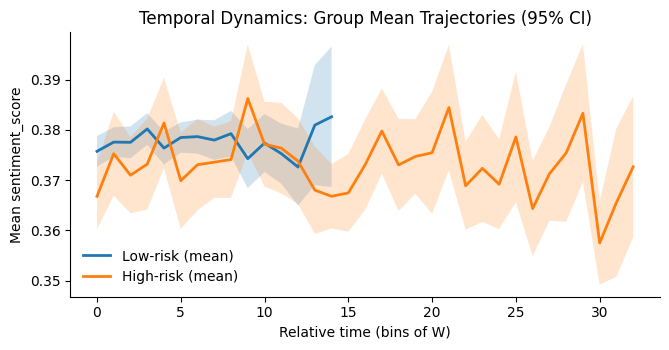

Saved: temporal_group_mean_ci.pdf
Included providers: {'High-risk': 21, 'Low-risk': 174}
Max relative time shown: {'High-risk': 32, 'Low-risk': 14}


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Paper-friendly group plot
# Mean + 95% CI band
# =========================

# ---- CONFIG ----
metric_col = "sentiment_score"   # change if you want
freq = "W"                       # "W" weekly or "M" monthly (monthly = smoother)
min_bins = 6                     # minimum number of time bins/provider to include
min_providers_per_bin = 8        # bins with < this many providers are dropped (stability)
out_pdf = "temporal_group_mean_ci.pdf"

# ---- Prepare notes ----
tmp = notes.copy()
tmp["PROVIDER_ID"] = tmp["PROVIDER_ID"].astype(str)
tmp["DATETIME"] = pd.to_datetime(tmp["DATETIME"], errors="coerce")
tmp = tmp.dropna(subset=["DATETIME", "PROVIDER_ID", metric_col]).copy()

# ---- Prepare labels (High vs Low) ----
lab = labels.copy()
lab.index = lab.index.map(str)

if "RISK_LABEL" in lab.columns:
    high_ids = set(lab[lab["RISK_LABEL"].astype(str).str.lower() == "high"].index)
    low_ids  = set(lab[lab["RISK_LABEL"].astype(str).str.lower() == "low"].index)
elif "BURNOUT_LABEL" in lab.columns:
    high_ids = set(lab[lab["BURNOUT_LABEL"] == 1].index)
    low_ids  = set(lab[lab["BURNOUT_LABEL"] == 0].index)
else:
    raise KeyError("labels must contain either RISK_LABEL or BURNOUT_LABEL")

# ✅ FIX: avoid np.where with np.nan (string dtype issue)
tmp["GROUP"] = pd.Series(index=tmp.index, dtype="object")
tmp.loc[tmp["PROVIDER_ID"].isin(high_ids), "GROUP"] = "High-risk"
tmp.loc[tmp["PROVIDER_ID"].isin(low_ids),  "GROUP"] = "Low-risk"
tmp = tmp.dropna(subset=["GROUP"]).copy()

# ---- Bin time ----
tmp["BIN"] = tmp["DATETIME"].dt.to_period(freq).dt.to_timestamp()

# Provider-level mean per bin (so heavy writers don't dominate)
prov_bin = (
    tmp.groupby(["GROUP", "PROVIDER_ID", "BIN"])[metric_col]
       .mean()
       .reset_index()
       .sort_values(["GROUP", "PROVIDER_ID", "BIN"])
)

# Filter providers with enough bins
bin_counts = prov_bin.groupby(["GROUP","PROVIDER_ID"])["BIN"].nunique().rename("n_bins").reset_index()
eligible = bin_counts[bin_counts["n_bins"] >= min_bins][["GROUP","PROVIDER_ID"]]
prov_bin = prov_bin.merge(eligible, on=["GROUP","PROVIDER_ID"], how="inner")

# Re-index time per provider as "relative time" (0,1,2...) so we can average trajectories
prov_bin["t_rel"] = prov_bin.groupby(["GROUP","PROVIDER_ID"]).cumcount()

# Aggregate across providers at each relative time
agg = (
    prov_bin.groupby(["GROUP","t_rel"])[metric_col]
            .agg(["mean","std","count"])
            .reset_index()
            .rename(columns={"mean":"mu","std":"sd","count":"n"})
)

# Drop unstable time points
agg = agg[agg["n"] >= min_providers_per_bin].copy()

# 95% CI: mu ± 1.96 * sd/sqrt(n)
agg["se"] = agg["sd"] / np.sqrt(agg["n"].clip(lower=1))
agg["ci"] = 1.96 * agg["se"]
agg["lo"] = agg["mu"] - agg["ci"]
agg["hi"] = agg["mu"] + agg["ci"]

# ---- Plot ----
plt.figure(figsize=(6.8, 3.6))

for group in ["Low-risk", "High-risk"]:
    g = agg[agg["GROUP"] == group].sort_values("t_rel")
    if g.empty:
        continue
    x = g["t_rel"].values
    y = g["mu"].values
    lo = g["lo"].values
    hi = g["hi"].values

    plt.plot(x, y, linewidth=2, label=f"{group} (mean)")
    plt.fill_between(x, lo, hi, alpha=0.2)

plt.xlabel(f"Relative time (bins of {freq})")
plt.ylabel(f"Mean {metric_col}")
plt.title("Temporal Dynamics: Group Mean Trajectories (95% CI)")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend(frameon=False, loc="best")
plt.tight_layout()

plt.savefig(out_pdf, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_pdf}")
print("Included providers:", prov_bin.groupby("GROUP")["PROVIDER_ID"].nunique().to_dict())
print("Max relative time shown:", agg.groupby("GROUP")["t_rel"].max().to_dict())